# Tuned DGM Model Analysis

This notebook compares observed DGM (`inputs/DGM_Valid_CAO.csv`) with model outputs from `Unit_WorM3_CAO_All_Calib_Direct.py`.
It uses optimized `ko_UVA` and `RHg_UVA` coefficients and reports baseline vs tuned statistics and plots.

In [1]:
from pathlib import Path
import os
import sys

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

script_name = 'Unit_WorM3_CAO_All_Calib_Direct.py'
here = Path.cwd().resolve()
candidates = [
    here,
    *here.parents,
    here / 'Mercury-arctic',
    Path.home() / 'Mercury-arctic',
    Path('/home/hiskim1/Mercury-arctic'),
]

repo_root = None
for cand in candidates:
    if (cand / script_name).exists():
        repo_root = cand.resolve()
        break

if repo_root is None:
    raise FileNotFoundError(f'Cannot locate {script_name} from working directory: {here}')

os.chdir(repo_root)
if str(repo_root) not in sys.path:
    sys.path.insert(0, str(repo_root))

from Unit_WorM3_CAO_All_Calib_Direct import run_model

BEST_COEFFS = {
    'ko_uva_num': 0.350407009078024,
    'rhg_uva_a': -0.02243776483632441,
    'rhg_uva_b': 1.4911911655729884,
    'rhg_uva_c': -23.612521190306616,
}

print('Working directory:', Path.cwd())
print('Best coefficients:', BEST_COEFFS)


Working directory: /home/hiskim1/Mercury-arctic
Best coefficients: {'ko_uva_num': 0.350407009078024, 'rhg_uva_a': -0.02243776483632441, 'rhg_uva_b': 1.4911911655729884, 'rhg_uva_c': -23.612521190306616}


In [2]:
# Baseline model outputs (already generated by default run)
baseline_df = pd.read_csv('outputs/Hg_budget_summary.csv')
baseline_metrics = pd.read_csv('outputs/Hg_model_metrics.csv')

# Tuned model outputs (recompute to ensure consistency with BEST_COEFFS)
tuned_df, tuned_metrics = run_model(
    input_csv='inputs/DGM_Valid_CAO.csv',
    output_summary_csv='outputs/Hg_budget_summary_tuned_best.csv',
    output_metrics_csv='outputs/Hg_model_metrics_tuned_best.csv',
    tuning=BEST_COEFFS,
    verbose=False,
)

display(baseline_df.head(3))
display(tuned_df.head(3))

,RowID,Temperature,Salinity,SeaIce,WindSpeed,Hg0_water,DGM_obs,HgII_water,Hg0_air,GEM_obs,...,Red_Bio,Ox_UVB,Ox_UVA,Ox_Dark,Ox_Bio,a_443,NSE_num,NSE_den,PBIAS_num,PBIAS_den
0,1,-0.444,30.078,0.79559,9.798,0.153203,0.185,0.828668,1.150837,1.128,...,0.000283,0.000167,0.003295,0.00036,0.000460,0.114439,0.001011,0.004153,3.179681,0.185
1,2,-0.431,30.348,0.85288,11.359,0.182477,0.191,0.879208,1.168908,1.127,...,0.000252,0.000124,0.002439,0.00036,0.000410,0.111999,0.000073,0.004962,0.852268,0.191
2,3,-0.509,30.420,0.76806,10.656,0.170982,0.175,0.857654,1.196415,1.123,...,0.000349,0.000189,0.003659,0.00036,0.000567,0.111348,0.000016,0.002964,0.401801,0.175


,RowID,Temperature,Salinity,SeaIce,WindSpeed,Hg0_water,DGM_obs,HgII_water,Hg0_air,GEM_obs,...,Red_Bio,Ox_UVB,Ox_UVA,Ox_Dark,Ox_Bio,a_443,NSE_num,NSE_den,PBIAS_num,PBIAS_den
0,1,-0.444,30.078,0.79559,9.798,0.165166,0.185,0.802258,1.159623,1.128,...,0.000283,0.000167,0.003396,0.00036,0.000460,0.114439,0.000393,0.004153,1.983410,0.185
1,2,-0.431,30.348,0.85288,11.359,0.195154,0.191,0.856337,1.177922,1.127,...,0.000252,0.000124,0.002514,0.00036,0.000410,0.111999,0.000017,0.004962,-0.415438,0.191
2,3,-0.509,30.420,0.76806,10.656,0.185596,0.175,0.826392,1.210660,1.123,...,0.000349,0.000189,0.003771,0.00036,0.000567,0.111348,0.000112,0.002964,-1.059625,0.175


In [3]:
def summarize_fit(df: pd.DataFrame):
    obs = df['DGM_obs'].to_numpy(dtype=float)
    sim = df['Hg0_water'].to_numpy(dtype=float)
    sal = df['Salinity'].to_numpy(dtype=float)
    valid = np.isfinite(obs) & np.isfinite(sim) & np.isfinite(sal)
    obs = obs[valid]
    sim = sim[valid]
    sal = sal[valid]

    p = np.polyfit(obs, sim, 1)
    slope = float(p[0])
    intercept = float(p[1])
    sim_fit = slope * obs + intercept

    ss_res_fit = float(np.sum((sim - sim_fit) ** 2))
    ss_tot_fit = float(np.sum((sim - np.mean(sim)) ** 2))
    r2_reg = 1 - ss_res_fit / ss_tot_fit

    obs_mean = float(np.mean(obs))
    sim_mean = float(np.mean(sim))
    num = float(np.sum((obs - obs_mean) * (sim - sim_mean)))
    den = float(np.sqrt(np.sum((obs - obs_mean) ** 2) * np.sum((sim - sim_mean) ** 2)))
    r = num / den
    r2_corr = r ** 2

    rmse = float(np.sqrt(np.mean((sim - obs) ** 2)))
    pbias = float(100 * np.sum(obs - sim) / np.sum(obs))
    mean_bias = float(np.mean(sim - obs))

    slope_obs_sal = float(np.polyfit(sal, obs, 1)[0])
    slope_sim_sal = float(np.polyfit(sal, sim, 1)[0])

    return {
        'N': int(obs.size),
        'R2_reg': r2_reg,
        'R2_corr': r2_corr,
        'r': r,
        'RMSE': rmse,
        'Slope': slope,
        'Intercept': intercept,
        'PBIAS_percent': pbias,
        'MeanBias': mean_bias,
        'SalinitySlope_obs': slope_obs_sal,
        'SalinitySlope_model': slope_sim_sal,
        'SalinitySlope_gap': slope_sim_sal - slope_obs_sal,
    }

base_stats = summarize_fit(baseline_df)
tuned_stats = summarize_fit(tuned_df)

stats_df = pd.DataFrame([base_stats, tuned_stats], index=['baseline', 'tuned'])
display(stats_df)
display((stats_df.loc['tuned'] - stats_df.loc['baseline']).to_frame('tuned_minus_baseline').T)

,N,R2_reg,R2_corr,r,RMSE,Slope,Intercept,PBIAS_percent,MeanBias,SalinitySlope_obs,SalinitySlope_model,SalinitySlope_gap
baseline,76,0.730229,0.730229,0.854534,0.026672,0.667184,0.026644,9.982687,-0.011416,0.040052,0.031662,-8.390373e-03
tuned,76,0.781661,0.781661,0.884116,0.022146,0.849179,0.013102,3.624375,-0.004145,0.040052,0.040052,1.674196e-10


,N,R2_reg,R2_corr,r,RMSE,Slope,Intercept,PBIAS_percent,MeanBias,SalinitySlope_obs,SalinitySlope_model,SalinitySlope_gap
tuned_minus_baseline,0.0,0.051432,0.051432,0.029582,-0.004525,0.181995,-0.013541,-6.358311,0.007271,0.0,0.00839,0.00839


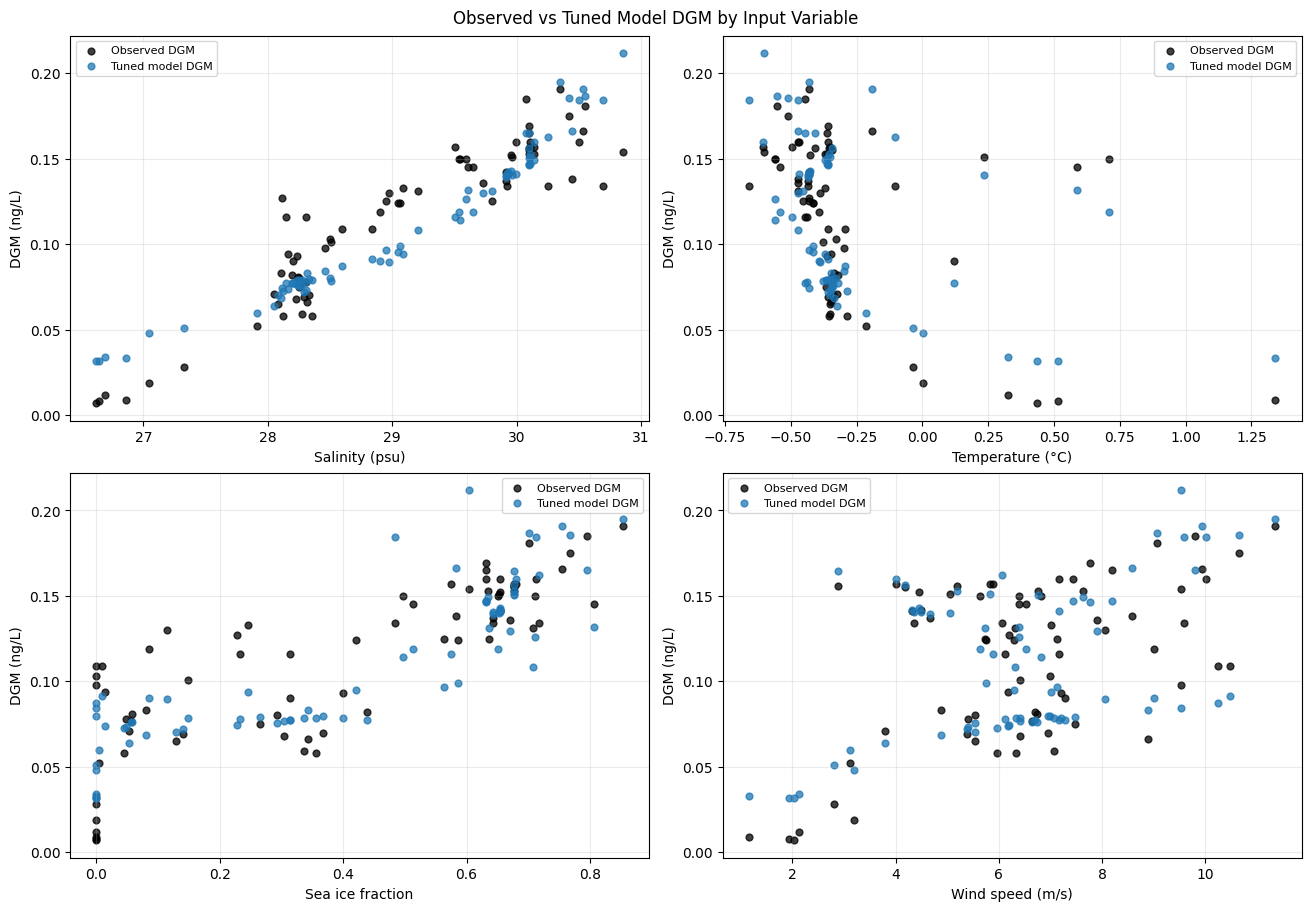

In [4]:
# Variable-wise comparison: observed DGM vs tuned model DGM
fig, axes = plt.subplots(2, 2, figsize=(13, 9), constrained_layout=True)
specs = [
    ('Salinity', 'Salinity (psu)'),
    ('Temperature', 'Temperature (°C)'),
    ('SeaIce', 'Sea ice fraction'),
    ('WindSpeed', 'Wind speed (m/s)'),
]

for ax, (col, label) in zip(axes.ravel(), specs):
    x = tuned_df[col].to_numpy(dtype=float)
    y_obs = tuned_df['DGM_obs'].to_numpy(dtype=float)
    y_sim = tuned_df['Hg0_water'].to_numpy(dtype=float)

    ax.scatter(x, y_obs, s=24, alpha=0.75, label='Observed DGM', color='black')
    ax.scatter(x, y_sim, s=24, alpha=0.75, label='Tuned model DGM', color='tab:blue')
    ax.set_xlabel(label)
    ax.set_ylabel('DGM (ng/L)')
    ax.grid(True, alpha=0.25)
    ax.legend(loc='best', fontsize=8)

fig.suptitle('Observed vs Tuned Model DGM by Input Variable')
fig.savefig('fig_tuned_variable_comparison.png', dpi=220)
plt.show()

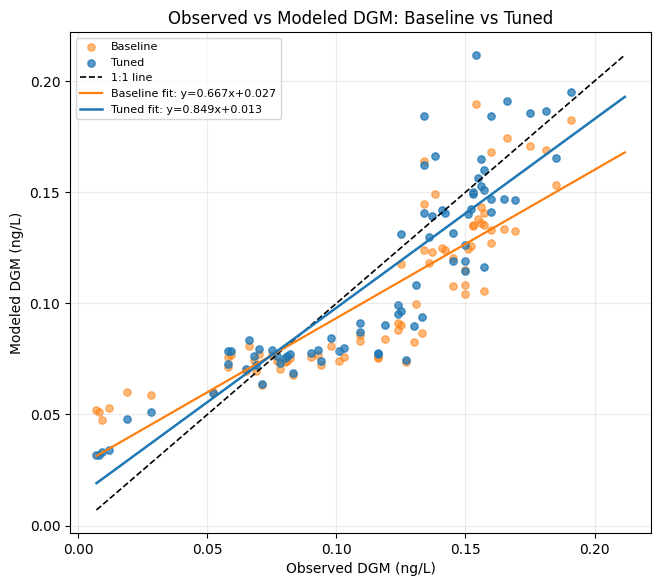

In [5]:
# Observed vs model DGM relationship (baseline and tuned)
fig, ax = plt.subplots(figsize=(7.5, 6.5))

obs_base = baseline_df['DGM_obs'].to_numpy(dtype=float)
sim_base = baseline_df['Hg0_water'].to_numpy(dtype=float)
obs_tune = tuned_df['DGM_obs'].to_numpy(dtype=float)
sim_tune = tuned_df['Hg0_water'].to_numpy(dtype=float)

ax.scatter(obs_base, sim_base, s=28, alpha=0.55, label='Baseline', color='tab:orange')
ax.scatter(obs_tune, sim_tune, s=28, alpha=0.75, label='Tuned', color='tab:blue')

mn = float(min(obs_tune.min(), sim_tune.min(), obs_base.min(), sim_base.min()))
mx = float(max(obs_tune.max(), sim_tune.max(), obs_base.max(), sim_base.max()))
ax.plot([mn, mx], [mn, mx], 'k--', lw=1.2, label='1:1 line')

m_b, b_b = np.polyfit(obs_base, sim_base, 1)
m_t, b_t = np.polyfit(obs_tune, sim_tune, 1)
xline = np.linspace(mn, mx, 200)
ax.plot(xline, m_b * xline + b_b, color='tab:orange', lw=1.6, label=f'Baseline fit: y={m_b:.3f}x+{b_b:.3f}')
ax.plot(xline, m_t * xline + b_t, color='tab:blue', lw=1.8, label=f'Tuned fit: y={m_t:.3f}x+{b_t:.3f}')

ax.set_xlabel('Observed DGM (ng/L)')
ax.set_ylabel('Modeled DGM (ng/L)')
ax.set_title('Observed vs Modeled DGM: Baseline vs Tuned')
ax.grid(True, alpha=0.25)
ax.legend(fontsize=8)
fig.savefig('fig_obs_vs_model_baseline_vs_tuned.png', dpi=220)
plt.show()